# Exploratory Data Analysis - Maternal Health Risk

This notebook explores the cleaned Maternal Health Risk dataset (UCI Machine Learning Repository) ahead of model training [1]. The data was collected from hospitals, clinics, and maternal health care centers in rural Bangladesh via an IoT-based monitoring system [1], and includes six health indicators used to predict a patient's pregnancy risk level (low, mid or high).

Cleaning and feature engineering (removing invalid heart rate entries, and adding PulsePressure, HasHypertension and AgeBracket) were done separately via SQL, see `src/clean_data.py`. This notebook picks up from the cleaned, feature-engineered database.

## Loading the Data
Connecting to the cleaned SQLite database and pulling the full table into a dataframe for exploration.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
conn = sqlite3.connect("../data/maternal_health_risk.db")
df = pd.read_sql_query("SELECT * FROM maternal_health_risk", conn)

In [4]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,PulsePressure,HasHypertension,AgeBracket
0,25,130,80,15.0,98.0,86,high risk,50,0,reproductive_age
1,35,140,90,13.0,98.0,70,high risk,50,1,advanced_maternal_age
2,29,90,70,8.0,100.0,80,high risk,20,0,reproductive_age
3,30,140,85,7.0,98.0,70,high risk,55,1,reproductive_age
4,35,120,60,6.1,98.0,76,low risk,60,0,advanced_maternal_age


## First Look

`describe()` surfaces summary statistics across all numeric columns. Most values fall within expected clinical ranges, but two things stand out:

- **Age** ranges from 10 to 70. Both ends look implausible for pregnancy and need a closer look.
- **Blood sugar (BS)** has a max of 19 mmol/L. This is high, but not necessarily impossible for severe and poorly controlled diabetes. Worth checking how many rows this affects.

In [5]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,PulsePressure,HasHypertension
count,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000
mean,29.899209,113.184783,76.463439,8.727619,98.666403,74.434783,36.721344,0.285573
std,13.473560,18.419618,13.899372,3.296583,1.372421,7.521857,11.375239,0.451910
min,10.000000,70.000000,49.000000,6.000000,98.000000,60.000000,8.000000,0.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,30.000000,0.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,35.000000,0.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000,40.000000,1.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,75.000000,1.000000


## Data Quality Check: Age

Investigating the implausible age values (10 and 70) found in the summary statistics above, to decide whether they're genuine outliers or likely data entry errors.

In [10]:
df[(df["Age"] < 12) | (df["Age"] >= 65)]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,PulsePressure,HasHypertension,AgeBracket
19,10,70,50,6.9,98.0,70,low risk,20,0,teen
250,10,85,65,6.9,98.0,70,low risk,20,0,teen
322,65,90,60,6.9,98.0,70,low risk,30,0,advanced_maternal_age
326,66,85,60,6.9,98.0,86,low risk,25,0,advanced_maternal_age
338,70,85,60,6.9,102.0,70,low risk,25,0,advanced_maternal_age
339,65,120,90,6.9,103.0,76,low risk,30,1,advanced_maternal_age
435,65,130,80,15.0,98.0,86,high risk,50,0,advanced_maternal_age
669,10,100,50,6.0,99.0,70,mid risk,50,0,teen
848,10,100,50,6.0,99.0,70,mid risk,50,0,teen


### Finding: Extreme age values

Filtering for `Age < 12` (below the typical age of menarche) surfaces 4 rows, all at exactly age 10, two of which are exact duplicates of each other across every column. Filtering for `Age >= 65` surfaces 5 rows in the 65-70 range.

These values were not treated as errors, and were left in the dataset unchanged.

Early/child pregnancy is a documented occurrence in some rural areas of Bangladesh — the population this dataset was collected from — so a small number of very young ages cannot be assumed to be data entry errors. However, the exact duplication in two of the four age-10 rows, combined with the absence of any values between ages 10 and 12, suggests these may partly reflect repeated records rather than four independent patients.

This is documented as a known limitation of the dataset rather than corrected, consistent with how published work using this dataset has handled it (no exclusion of age extremes; only the heart rate=7 case is commonly flagged and removed [2-4]).

## Class Balance

Before looking at individual features, it's worth checking how the three risk levels are distributed across the dataset.

<Axes: xlabel='RiskLevel', ylabel='count'>

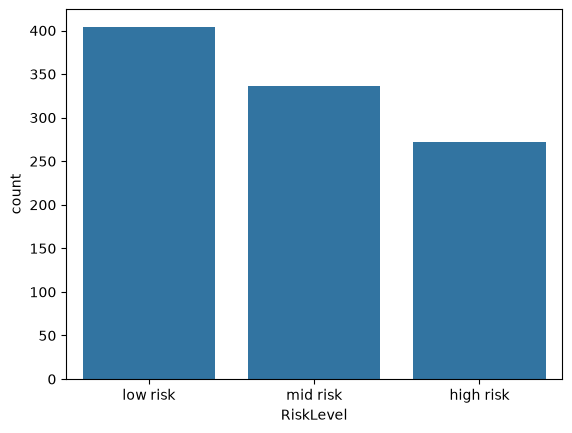

In [14]:
sns.countplot(data=df, x="RiskLevel", order=["low risk", "mid risk", "high risk"])

## Feature Relationships with Risk Level

Next, looking at how individual features relate to risk level, starting with blood sugar. This is a well-established pregnancy risk indicator (gestational diabetes) [5].

<Axes: xlabel='RiskLevel', ylabel='BS'>

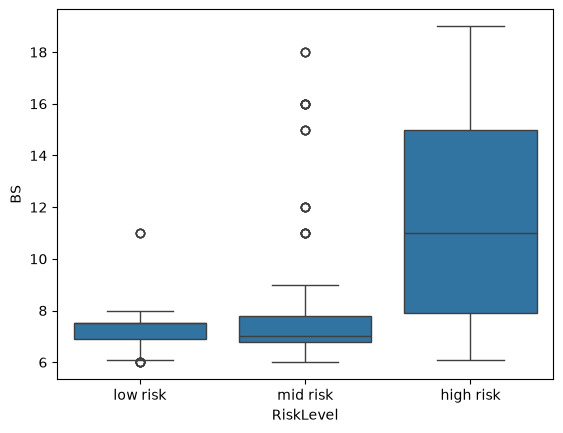

In [15]:
sns.boxplot(data=df, x="RiskLevel", y="BS", order=["low risk", "mid risk", "high risk"])

Blood sugar shows a clear relationship with risk level: both the median and the spread of values increase from low to high risk. Low-risk patients cluster tightly around a lower blood sugar range, while high-risk patients show a much wider spread, with the median also shifted noticeably higher.

This is consistent with gestational diabetes, a well-established pregnancy risk factor associated with gestational hypertension, pre-eclampsia, and increased likelihood of cesarean delivery [5], and suggests blood sugar will likely be a strong predictive feature for the model.

## Age

Checking whether age shows a similar relationship with risk level. The dataset itself spans a wide age range, collected from hospitals, clinics, and maternal health care centers in rural Bangladesh [1]. Given the earlier finding that both very young and older ages exist in this dataset, and that both extremes are associated with elevated pregnancy risk clinically [7-10], the relationship may be less linear than blood sugar's [5].

<Axes: xlabel='RiskLevel', ylabel='Age'>

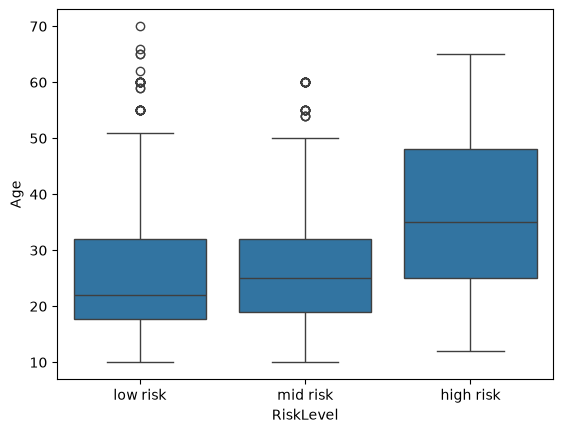

In [16]:
sns.boxplot(data=df, x="RiskLevel", y="Age", order=["low risk", "mid risk", "high risk"])

Unlike blood sugar, age doesn't show a clean, steadily increasing trend across risk levels. Low risk and mid risk groups look nearly identical in both median age and spread. High risk is the outlier: both its median (~35) and its spread shift noticeably higher, with the upper range extending to 65 without being flagged as unusual.

Notably, several patients aged 55-70 appear as individual outlier points within the low and mid risk groups — meaning some older patients are still classified as low or mid risk, complicating a simple "older age means higher risk" interpretation. 

This is consistent with the clinical literature on advanced maternal age, which treats age as one risk factor among several rather than a deterministic one, and notes ongoing debate over where exactly increased risk becomes significant [7-10]. Age alone does not appear to cleanly separate risk groups the way blood sugar does, suggesting the model will likely need to combine age with other features rather than relying on it in isolation.

## Blood Pressure (Systolic, Diastolic, and Pulse Pressure)

Checking both raw blood pressure components and the engineered PulsePressure feature against risk level, together since they're closely related.

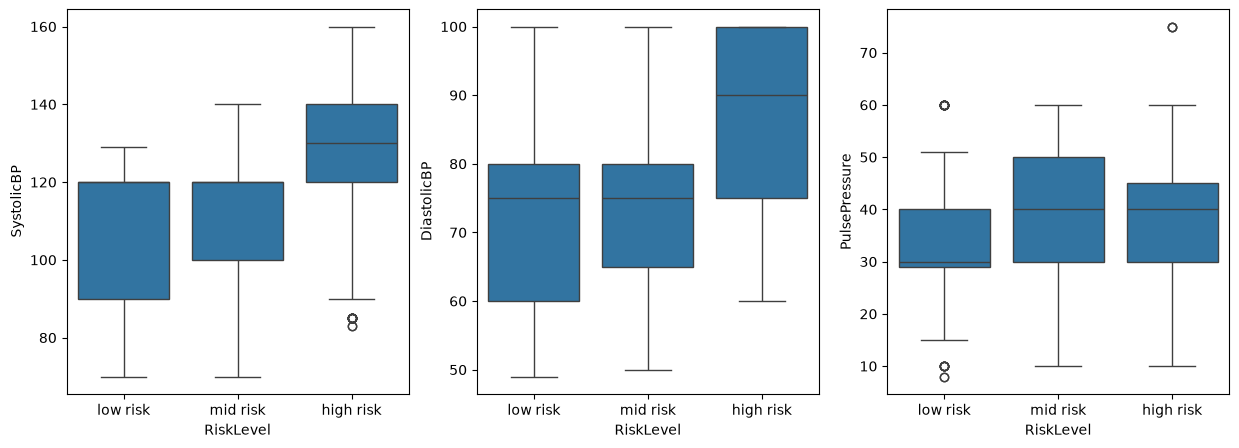

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(data=df, x="RiskLevel", y="SystolicBP", order=["low risk", "mid risk", "high risk"], ax=axes[0])
sns.boxplot(data=df, x="RiskLevel", y="DiastolicBP", order=["low risk", "mid risk", "high risk"], ax=axes[1])
sns.boxplot(data=df, x="RiskLevel", y="PulsePressure", order=["low risk", "mid risk", "high risk"], ax=axes[2])
plt.show()

Systolic and diastolic blood pressure follow a pattern similar to age: low risk and mid risk look nearly identical, while high risk clearly separates, with both a higher median and wider spread. Diastolic pressure especially, jumps from a median of ~75 in low/mid risk to ~90 in high risk. This is consistent with hypertension being a recognized contributor to pregnancy complications, including preeclampsia [11].

PulsePressure tells a different story. Rather than high risk standing apart, it's low risk that separates from the other two. Low risk shows a lower, tighter pulse pressure (median ~30), while mid and high risk look similar to each other (both median ~40). This suggests pulse pressure may help distinguish low-risk patients from the rest, but is less useful for separating mid from high risk specifically.

## AgeBracket and HasHypertension

Since both AgeBracket and HasHypertension are categories rather than continuous numbers, a boxplot doesn't apply here, instead, comparing how RiskLevel is distributed within each category.

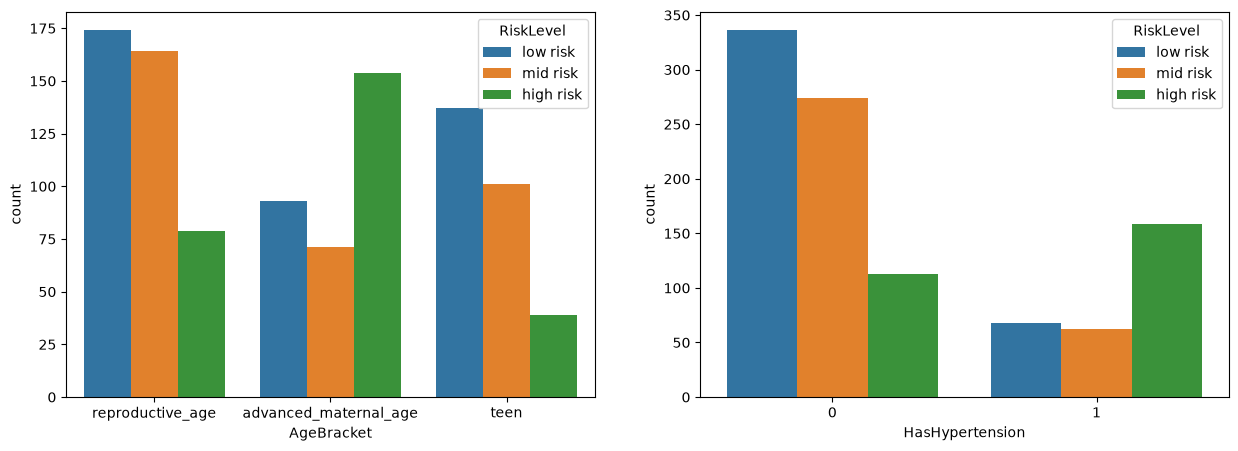

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, x="AgeBracket", hue="RiskLevel", hue_order=["low risk", "mid risk", "high risk"], ax=axes[0])
sns.countplot(data=df, x="HasHypertension", hue="RiskLevel", hue_order=["low risk", "mid risk", "high risk"], ax=axes[1])
plt.show()

Both AgeBracket and HasHypertension show clear associations with risk level, though in different ways.

**AgeBracket:** in the reproductive_age and teen brackets, low risk is the most common outcome. This flips in the advanced_maternal_age bracket, where high risk becomes the largest group, reinforcing the earlier finding that age's relationship with risk is concentrated at the older end of the range, consistent with the clinical literature on advanced maternal age [7-10].

Notably, the teen bracket does not show a similarly elevated risk profile. Its distribution looks broadly similar to reproductive_age, with low risk still dominant. This is a useful nuance: while teenage pregnancy carries known clinical risks (documented separately in the literature [8]), it does not translate into a comparably strong high-risk skew *in this dataset* the way advanced maternal age does. This may reflect small sample size within the teen bracket, or the general nature of the specific risk factors measured here (blood pressure, blood sugar, etc.) rather than a contradiction of the wider clinical evidence.

**HasHypertension:** a much sharper split (0 = no hypertension, 1 = hypertension, per the SystolicBP >= 140 OR DiastolicBP >= 90 threshold defined earlier [6]). Patients without hypertension are predominantly low risk, while patients with hypertension are predominantly high risk — the clearest categorical relationship seen so far, consistent with hypertension's established role in pregnancy complications [11].

## BodyTemp and HeartRate

Checking the two remaining features, which are less obviously tied to pregnancy risk clinically than blood pressure or blood sugar. 

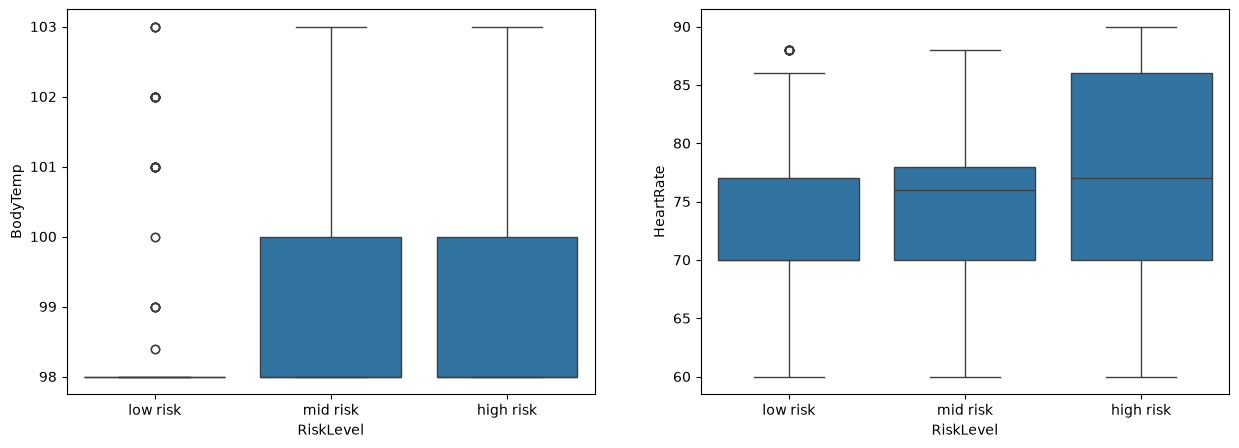

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x="RiskLevel", y="BodyTemp", order=["low risk", "mid risk", "high risk"], ax=axes[0])
sns.boxplot(data=df, x="RiskLevel", y="HeartRate", order=["low risk", "mid risk", "high risk"], ax=axes[1])
plt.show()

BodyTemp and HeartRate show weaker, more limited relationships with risk level compared to the other features.

**BodyTemp:** low risk is very tightly clustered around 98°F, with a handful of individual points (99-103°F) flagged as outliers. Mid risk and high risk, by contrast, both show a real spread from 98-100°F up to 103°F. The two groups look nearly identical to each other. This suggests body temperature may help separate low risk from mid/high risk, but doesn't distinguish mid from high risk at all.

**HeartRate:** the median stays fairly similar across all three groups (roughly 76-77 bpm), but high risk shows a noticeably wider spread than low or mid risk. This mirrors the variability pattern seen earlier with blood sugar, high risk appears to be a more heterogeneous group overall, not necessarily defined by one single elevated value, but by greater variability across several features.

## Correlation Between Features

Having looked at each feature individually against risk level, it's worth checking how the features relate to *each other*, both to spot redundancy (e.g. does PulsePressure just duplicate information already in SystolicBP/DiastolicBP) and to get one consolidated view of the numeric relationships in the dataset.

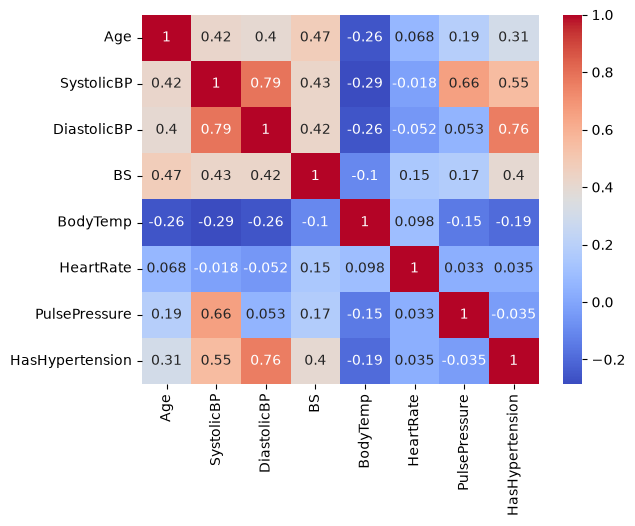

In [21]:
correlation_matrix = df[["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate", "PulsePressure", "HasHypertension"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()

A few things stand out from the correlation matrix:

**SystolicBP and DiastolicBP correlate strongly (0.79)**, as expected since both measure blood pressure. **DiastolicBP and HasHypertension correlate strongly too (0.76)**, unsurprising given the hypertension flag was derived directly from these values.

**PulsePressure correlates moderately with SystolicBP (0.66) but barely at all with DiastolicBP (0.053)**, despite being calculated as the difference between the two. This suggests PulsePressure isn't simply redundant with either raw blood pressure value; it appears to capture something closer to systolic pressure's signal specifically, rather than blending both equally.

**HeartRate stands out for the opposite reason: its correlations with every other feature are consistently close to zero.** This confirms the earlier boxplot finding that HeartRate behaves almost like an independent variable in this dataset, showing little relationship to risk level or to any other feature. This is a reasonable signal that HeartRate may contribute little predictive value to the model.

## Summary of Findings

- **Blood sugar (BS)** shows the clearest relationship with risk level: both median and spread increase from low to high risk, consistent with gestational diabetes as an established pregnancy risk factor [5]. Likely a strong predictive feature.

- **Age** does not increase risk cleanly or linearly. Low and mid risk look nearly identical; only high risk clearly separates, skewing older. The teen bracket does not show an elevated risk profile in this dataset, despite documented clinical risk [8], while advanced maternal age does [7-10].

- **Blood pressure (Systolic, Diastolic) and HasHypertension** show a strong relationship with risk level, particularly for high risk, consistent with hypertension's established role in pregnancy complications [11]. HasHypertension in particular produces the sharpest categorical split of any feature examined.

- **PulsePressure** separates low risk from the other two groups, but doesn't distinguish mid from high risk. Correlation analysis shows it's not simply redundant with either raw blood pressure value.

- **BodyTemp** weakly separates low risk from mid/high risk, but doesn't distinguish between mid and high.

- **HeartRate** shows almost no relationship with risk level or with any other feature in the dataset — the weakest feature examined, and a candidate for low predictive value in the model.

- Two data quality issues were identified and documented: an implausible heart rate value (7 bpm, removed [2-4]) and a small number of implausible age values (kept and documented as a limitation).

**Implication for modeling:** BS, blood pressure/HasHypertension, and to a lesser extent Age and PulsePressure appear to carry the strongest signal for predicting risk level. HeartRate appears to contribute little and may be a candidate for exclusion or de-prioritization when building the model.

## References

1. Ahmed, M., Kashem, M. A., Rahman, M., Khatun, S. (2020). Review and Analysis of Risk Factor of Maternal Health in Remote Area Using the Internet of Things (IoT). *Lecture Notes in Electrical Engineering*, vol 632. https://archive.ics.uci.edu/dataset/863/maternal+health+risk

2. Predicting maternal risk level using machine learning models. *PMC*. https://pmc.ncbi.nlm.nih.gov/articles/PMC11657143/

3. Deep hybrid model for maternal health risk classification in pregnancy: synergy of ANN and random forest. *Frontiers in Artificial Intelligence*. https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2023.1213436/full

4. Rickens, B. Maternal Health Risk (notebook analysis). https://bryanrickens.github.io/Notebooks/maternal.html

5. Gestational Diabetes Mellitus—Recent Literature Review. *PMC*. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9572242/

6. European Society of Cardiology / European Society of Hypertension. (2018). ESC-ESH Guidelines: Definition of hypertension and pressure goals during treatment. https://www.escardio.org/communities/councils/cardiology-practice/scientific-documents-and-publications/ejournal/volume-17/definition-of-hypertension-and-pressure-goals-during-treatment-esc-esh-guidelin/

7. Maternal age extremes and adverse pregnancy outcomes in low-resourced settings. *PMC*. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10715413/

8. The Definition of the Upper Limit of Adolescent Age in Terms of Adverse Pregnancy Outcomes. *PMC*. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8777262/

9. American College of Obstetricians and Gynecologists (ACOG). (2022). Pregnancy at Age 35 Years or Older: Obstetric Care Consensus. https://www.acog.org/clinical/clinical-guidance/obstetric-care-consensus/articles/2022/08/pregnancy-at-age-35-years-or-older

10. Advanced Maternal Age and Adverse Pregnancy Outcome: Evidence from a Large Contemporary Cohort. *PLOS ONE*. https://journals.plos.org/plosone/article?id=10.1371%2Fjournal.pone.0056583

11. A Comprehensive Review of Hypertension in Pregnancy. *PMC*. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3366228/